In [0]:
%pip install statsmodels pmdarima prophet langchain langchain-openai langchain-community openai
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


<Axes: xlabel='Year'>

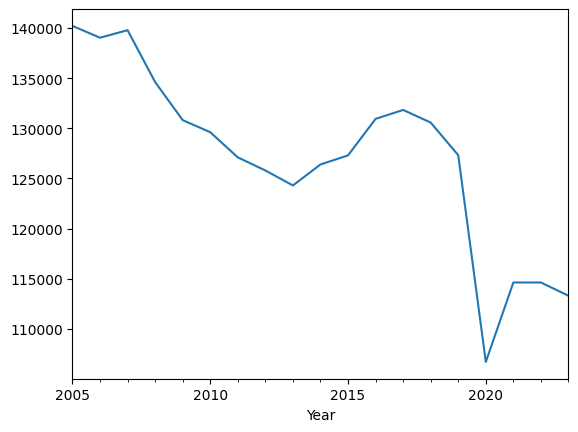

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

df = spark.read.table("workspace.default.cleaned_ghg_2005_2023")
df = df.toPandas()

# Filter Transport Sector
transport_df = df[df["Sector"] == "Transport"]

# Filter CO2 Greenhouse gas
greenhouse_gas_df = df[df["Greenhouse_gas"] == "CO2"]

# Aggregate National Level for Transport
transport_national = (transport_df.groupby(
    "Year")["TerritorialEmissions"].sum().reset_index())

# Convert 'Year' to datetime and set as index
transport_national["Year"] = pd.to_datetime(
    transport_national["Year"], format='%Y')
transport_national = transport_national.set_index("Year")

# Aggregate National Level for CO2 gas
CO2_National = (greenhouse_gas_df.groupby(
    "Year")["TerritorialEmissions"].sum().reset_index())

# Convert 'Year' to datetime and set as index
CO2_National["Year"] = pd.to_datetime(CO2_National["Year"], format='%Y')
CO2_National = CO2_National.set_index("Year")

# Create time series
ts = transport_national["TerritorialEmissions"].resample("YE").sum()
ts.head()

ts.plot()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 23.5 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


<Figure size 1200x500 with 0 Axes>

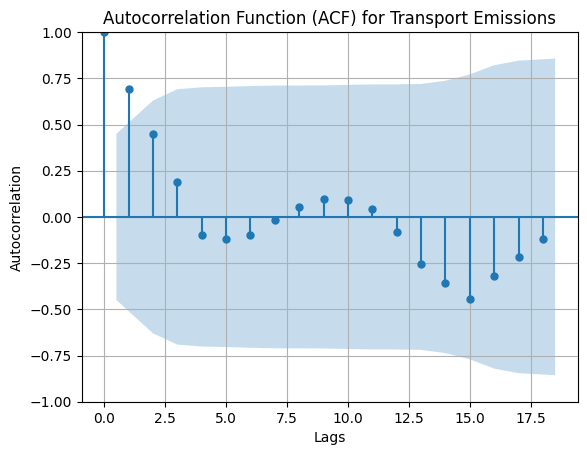

In [0]:
ts = transport_national["TerritorialEmissions"].resample("YE").sum()

# ACF plot for Transport Emissions
plt.figure(figsize=(12, 5))
plot_acf(ts, lags=len(ts)-1)
plt.title('Autocorrelation Function (ACF) for Transport Emissions')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

<Figure size 1200x500 with 0 Axes>

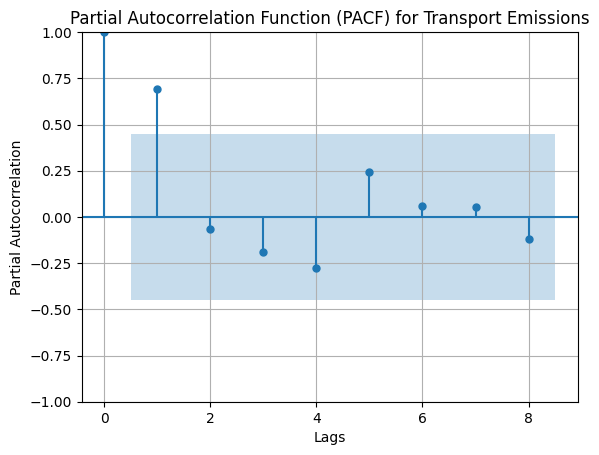

In [0]:
# PACF plot for Transport Emissions
plt.figure(figsize=(12, 5))
plot_pacf(ts, lags=min(10, len(ts)//2 - 1))
plt.title('Partial Autocorrelation Function (PACF) for Transport Emissions')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

<Figure size 1200x500 with 0 Axes>

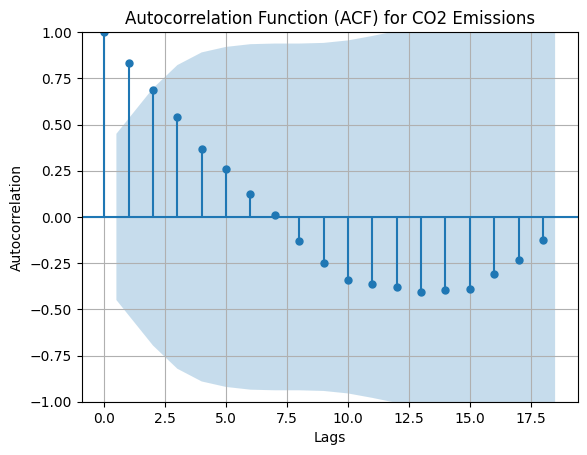

<Figure size 1200x500 with 0 Axes>

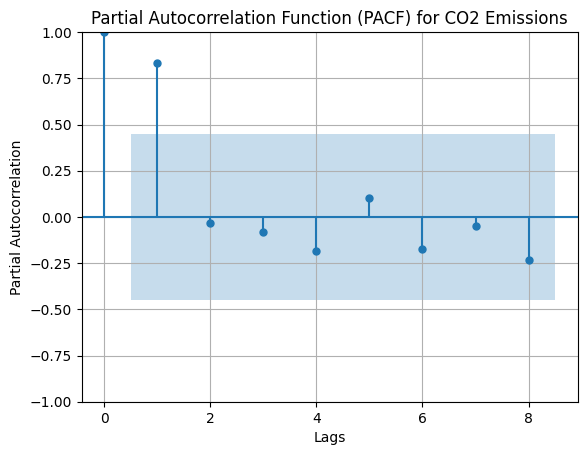

In [0]:
ts_co2 = CO2_National["TerritorialEmissions"].resample("YE").sum()

# ACF plot for CO2 Emissions
plt.figure(figsize=(12, 5))
plot_acf(ts_co2, lags=len(ts_co2)-1)
plt.title('Autocorrelation Function (ACF) for CO2 Emissions')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# PACF plot for CO2 Emissions
plt.figure(figsize=(12, 5))
plot_pacf(ts_co2, lags=8)
plt.title('Partial Autocorrelation Function (PACF) for CO2 Emissions')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [0]:
# Perform Augmented Dickey-Fuller test
result = adfuller(ts)

# Print the results
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

# Interpret the p-value
if result[1] <= 0.05:
    print("The series is likely stationary (reject the null hypothesis).")
elif result[1] > 0.05:
    print("The series is likely non-stationary (fail to reject the null hypothesis).")

ADF Statistic: -2.553276969082329
p-value: 0.10304349539408869
Critical Values:
	1%: -4.137829282407408
	5%: -3.1549724074074077
	10%: -2.7144769444444443
The series is likely non-stationary (fail to reject the null hypothesis).


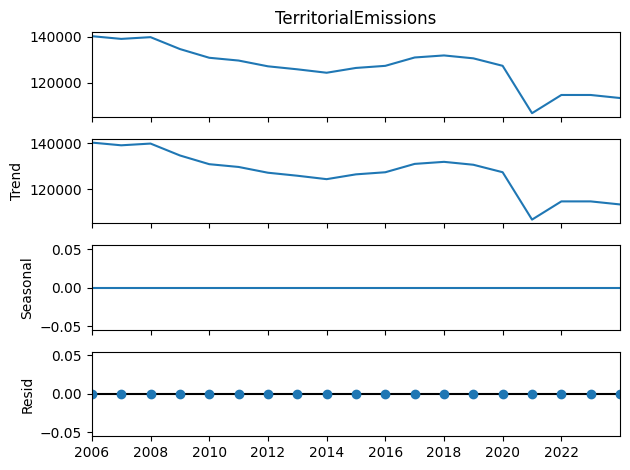

In [0]:
import statsmodels.api as sm

decomposition = sm.tsa.seasonal_decompose(ts, model='additive')
fig = decomposition.plot()
plt.show()

In [0]:
len(ts)
train = ts[:10]
test = ts[10:]
from pmdarima import auto_arima
auto_arima(train, m=1, seasonal= False, d=1, trace = True, error_action = "ignore", suppress_warnings = True, stepwise = True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=166.835, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=168.867, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=170.704, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=168.829, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.593 seconds


ARIMA(order=(0, 1, 0), scoring_args={}, suppress_warnings=True)

In [0]:
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.arima.model import ARIMA

p=range(0,8)
q=range(0,8)
d=range(0,2)
pdq_combination = list(itertools.product(p,d,q))
len(pdq_combination)
rmse = []
order1 = []

# Suppress specific warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

for pdq in pdq_combination:
  try:
    model = ARIMA(train, order = pdq).fit()
    pred = model.predict(start=len(train), end=(len(ts)-1))
    error = np.sqrt(mean_squared_error(test, pred))
    order1.append(pdq)
    rmse.append(error)
  except Exception as e:
    print(f"ARIMA{pdq} failed with error: {e}")
    continue

results = pd.DataFrame(index=order1, data = rmse, columns=["RMSE"])
results.to_csv("ARIMA_RESULTS.csv")

error = np.sqrt(mean_squared_error(test, pred))
error
test.mean(), np.sqrt(test.var())

(np.float64(121915.49867465223), np.float64(9516.332700619623))

<Axes: xlabel='Year'>

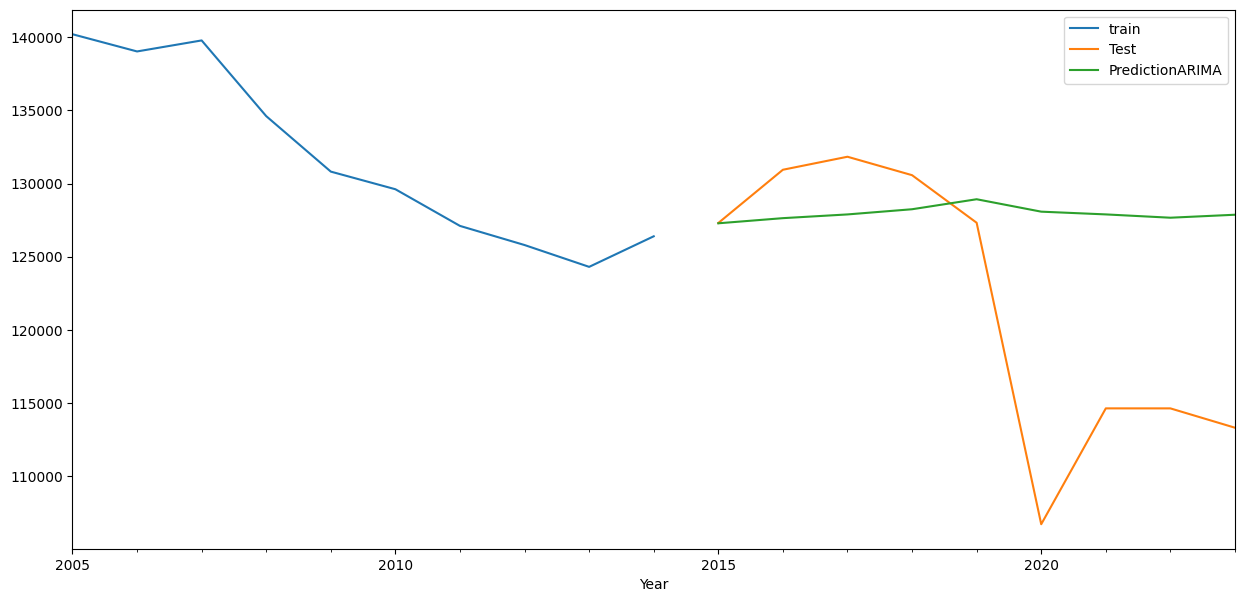

In [0]:
train.plot(legend=True, label = "train", figsize=(15, 7))
test.plot(legend=True, label = "Test")
pred.plot(legend=True, label = "PredictionARIMA")




<Axes: xlabel='Year'>

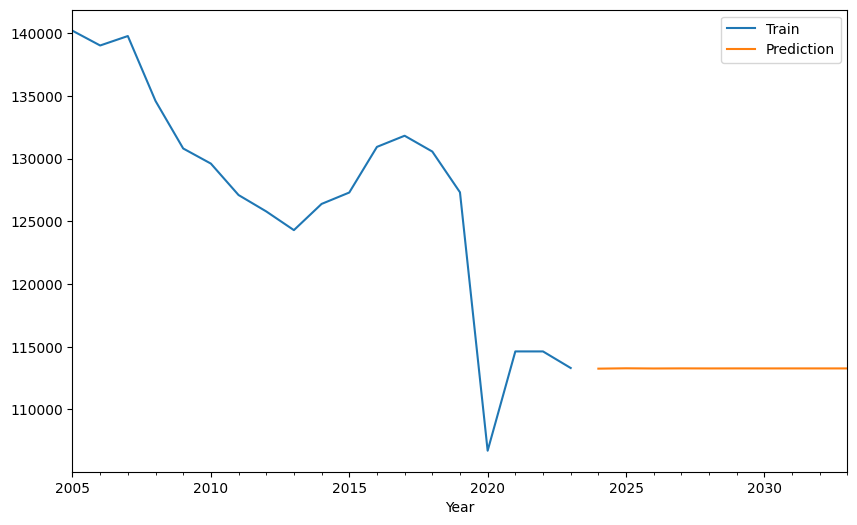

In [0]:
final_model = ARIMA(ts, order = (1,1,1)).fit()
prediction = final_model.predict(start=len(ts), end=len(ts) + 9) # Predict 10 steps into the future
ts.plot(legend = True, label = "Train", figsize = (10,6))
prediction.plot(legend = True, label = "Prediction")

In [0]:
from prophet import Prophet

# Prepare data for Prophet
# Prophet requires the columns to be named 'ds' (datestamp) and 'y' (value)
prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']

# Initialize and fit the Prophet model
m = Prophet()
m.fit(prophet_df)

# Create a dataframe for future predictions (e.g., next 10 years)
future = m.make_future_dataframe(periods=10, freq='Y')

# Make predictions
forecast = m.predict(future)

# Display the forecast for the next 10 years
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

22:34:41 - cmdstanpy - INFO - Chain [1] start processing
22:34:41 - cmdstanpy - INFO - Chain [1] done processing
/local_disk0/.ephemeral_nfs/envs/pythonEnv-3dc8fb04-b977-4387-9d79-e4a8bc695745/lib/python3.12/site-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


ds,yhat,yhat_lower,yhat_upper
2024-12-31T00:00:00.000Z,111254.9932591235,105389.31387820811,117702.57821155501
2025-12-31T00:00:00.000Z,111824.99899263032,105659.83210298001,118315.77304182651
2026-12-31T00:00:00.000Z,111703.91770322254,105415.07764752134,117368.14879394474
2027-12-31T00:00:00.000Z,110890.27404152413,104711.21455299955,116927.21068721134
2028-12-31T00:00:00.000Z,105834.41002297074,99896.04793165131,112175.31205068165
2029-12-31T00:00:00.000Z,106404.4157564894,99822.37618895534,112980.89615970434
2030-12-31T00:00:00.000Z,106283.33446706343,99812.00251764923,112702.74355770739
2031-12-31T00:00:00.000Z,105469.69080536634,98870.5133096732,111581.67043974187
2032-12-31T00:00:00.000Z,100413.82678684274,94329.86306279061,106761.34868170625
2033-12-31T00:00:00.000Z,100983.83252032266,94678.23790998744,107563.73295815822


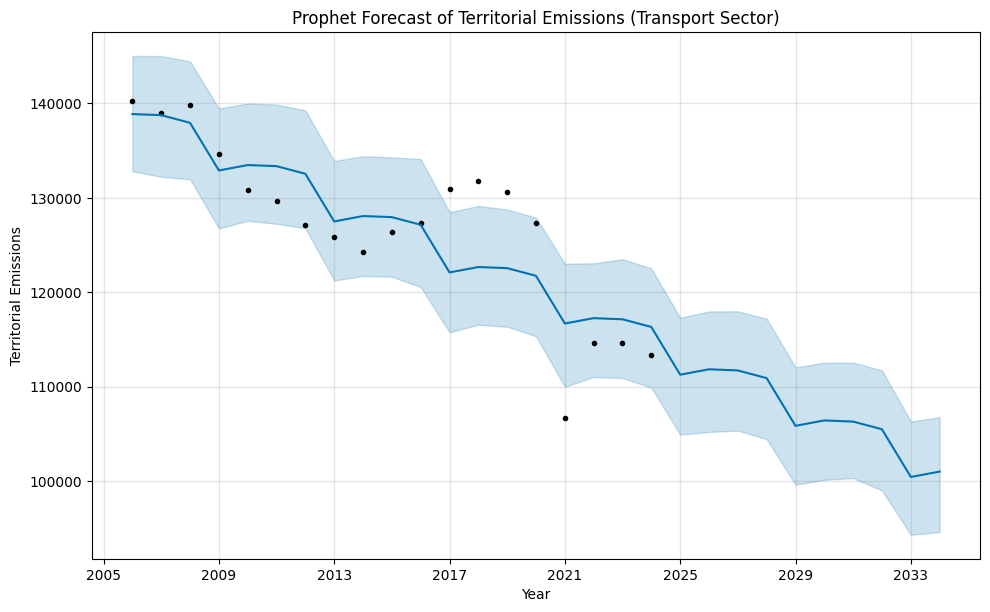

In [0]:
# Plot the forecast
fig = m.plot(forecast)
plt.title("Prophet Forecast of Territorial Emissions (Transport Sector)")
plt.xlabel("Year")
plt.ylabel("Territorial Emissions")
plt.show()

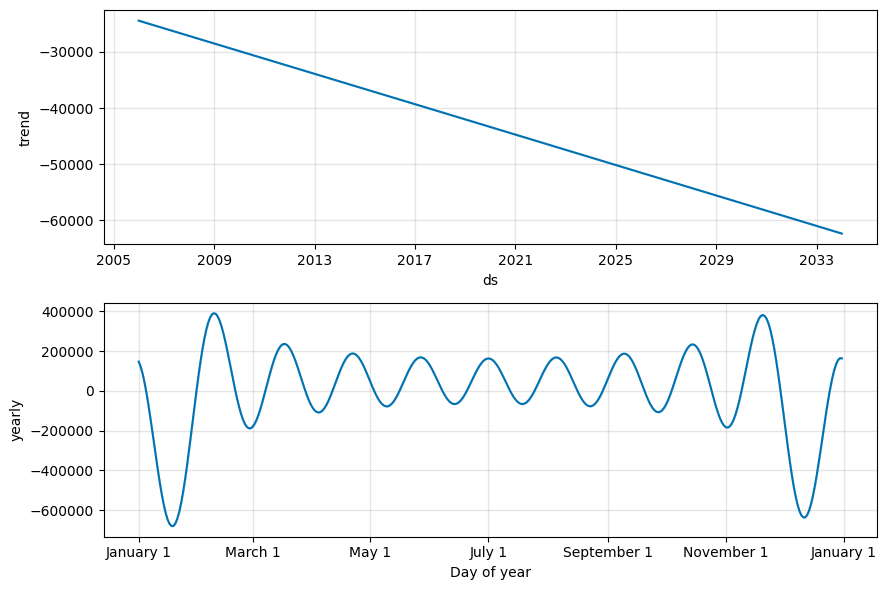

In [0]:
# Plot the components of the forecast (trend, seasonality)
fig2 = m.plot_components(forecast)
plt.show()

ds,y
2005-12-31T00:00:00.000Z,140207.586036492
2006-12-31T00:00:00.000Z,139030.083138741
2007-12-31T00:00:00.000Z,139783.383191507
2008-12-31T00:00:00.000Z,134607.553093511
2009-12-31T00:00:00.000Z,130815.200339249


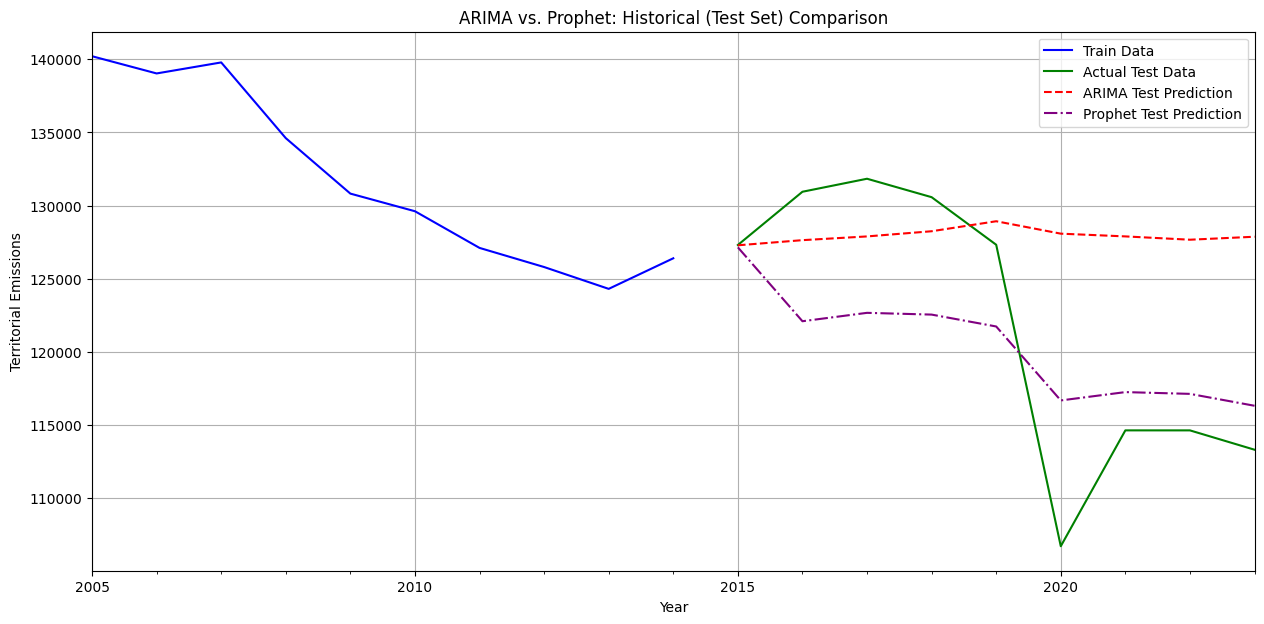

In [0]:
from prophet import Prophet

# Prepare data for Prophet
# Prophet requires the columns to be named 'ds' (datestamp) and 'y' (value)
prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']

# Display the first few rows to confirm format
display(prophet_df.head())
# Get Prophet predictions for the test period (assuming test.index aligns with forecast['ds'])
prophet_test_pred = forecast[forecast['ds'].isin(test.index)][['ds', 'yhat']].set_index('ds')['yhat']

# Get Prophet future predictions (after the historical data ends)
prophet_future_pred = forecast[forecast['ds'] > ts.index.max()][['ds', 'yhat']].set_index('ds')['yhat']

# Plotting Comparison - Historical (Test Period)
plt.figure(figsize=(15, 7))
train.plot(legend=True, label="Train Data", color='blue')
test.plot(legend=True, label="Actual Test Data", color='green')
pred.plot(legend=True, label="ARIMA Test Prediction", color='red', linestyle='--')
prophet_test_pred.plot(legend=True, label="Prophet Test Prediction", color='purple', linestyle='-.')
plt.title("ARIMA vs. Prophet: Historical (Test Set) Comparison")
plt.xlabel("Year")
plt.ylabel("Territorial Emissions")
plt.grid(True)
plt.show()

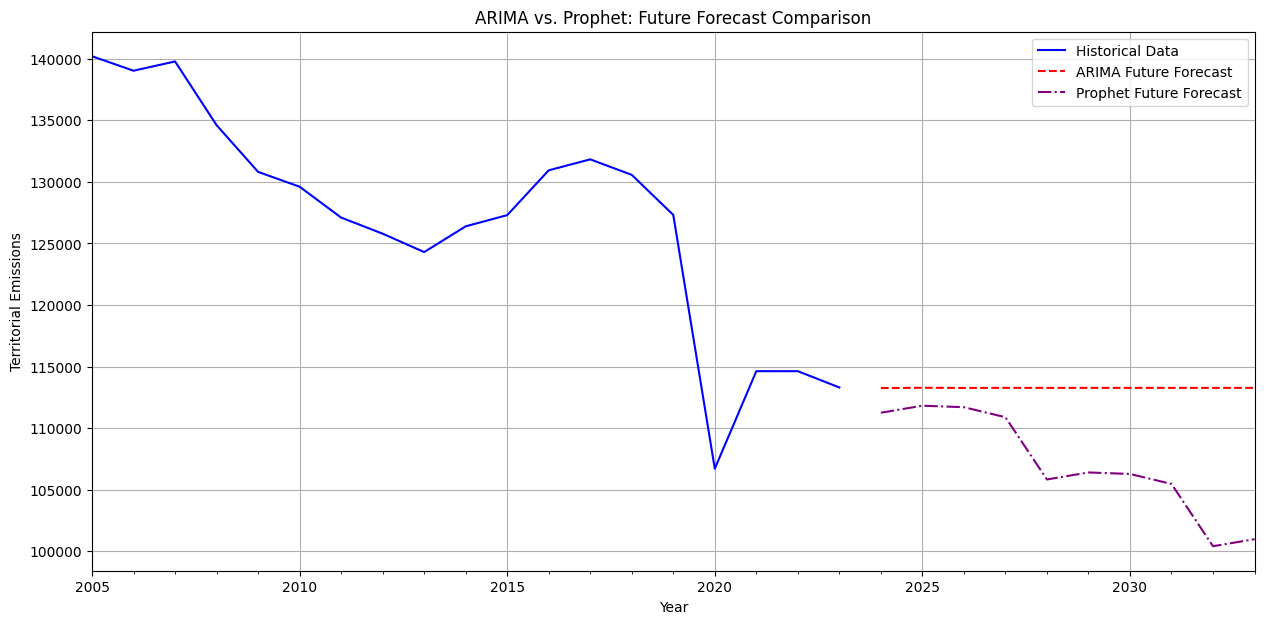

In [0]:
# Plotting Comparison - Future Forecast
plt.figure(figsize=(15, 7))
ts.plot(legend=True, label="Historical Data", color='blue')
prediction.plot(legend=True, label="ARIMA Future Forecast", color='red', linestyle='--')
prophet_future_pred.plot(legend=True, label="Prophet Future Forecast", color='purple', linestyle='-.')
plt.title("ARIMA vs. Prophet: Future Forecast Comparison")
plt.xlabel("Year")
plt.ylabel("Territorial Emissions")
plt.grid(True)
plt.show()

In [0]:
# Create the time series for CO2_National
ts_co2 = CO2_National["TerritorialEmissions"].resample("YE").sum()

# Split CO2_National data into train and test sets (similar to transport data)
len_ts_co2 = len(ts_co2)
train_co2_len = int(len_ts_co2 * 0.7)

train_co2 = ts_co2[:train_co2_len]
test_co2 = ts_co2[train_co2_len:]

print(f"Length of CO2 time series: {len_ts_co2}")
print(f"Length of CO2 training set: {len(train_co2)}")
print(f"Length of CO2 testing set: {len(test_co2)}")

display(train_co2.head())
display(test_co2.head())

# Perform Augmented Dickey-Fuller test for CO2_National
result_co2 = adfuller(ts_co2)

# Print the results
print('ADF Statistic (CO2):', result_co2[0])
print('p-value (CO2):', result_co2[1])
print('Critical Values (CO2):')
for key, value in result_co2[4].items():
    print(f'\t{key}: {value}')

# Interpret the p-value
if result_co2[1] <= 0.05:
    print("The CO2 series is likely stationary (reject the null hypothesis).")
elif result_co2[1] > 0.05:
    print("The CO2 series is likely non-stationary (fail to reject the null hypothesis).")

Length of CO2 time series: 19
Length of CO2 training set: 13
Length of CO2 testing set: 6


Year
2005-12-31    532010.908281
2006-12-31    530252.624274
2007-12-31    519095.510604
2008-12-31    507204.071435
2009-12-31    457696.456955
Freq: YE-DEC, Name: TerritorialEmissions, dtype: float64

Year
2018-12-31    349764.486489
2019-12-31    334246.381119
2020-12-31    301984.196906
2021-12-31    319170.103402
2022-12-31    296864.053196
Freq: YE-DEC, Name: TerritorialEmissions, dtype: float64

ADF Statistic (CO2): -0.41910795658236255
p-value (CO2): 0.9068592166369585
Critical Values (CO2):
	1%: -3.859073285322359
	5%: -3.0420456927297668
	10%: -2.6609064197530863
The CO2 series is likely non-stationary (fail to reject the null hypothesis).


In [0]:
import itertools
from sklearn.metrics import mean_squared_error
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Define the parameter ranges for p, d, q
p_co2 = range(0, 8)
q_co2 = range(0, 8)
d_co2 = range(0, 2) # d=0 or d=1 is common, given non-stationarity detected

pdq_combination_co2 = list(itertools.product(p_co2, d_co2, q_co2))
print(f"Total ARIMA combinations to test for CO2: {len(pdq_combination_co2)}")

rmse_co2 = []
order_co2 = []

# Suppress specific warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

for pdq in pdq_combination_co2:
    try:
        model_co2 = ARIMA(train_co2, order=pdq).fit()
        # Ensure prediction starts from the end of the training data
        pred_co2 = model_co2.predict(start=len(train_co2), end=(len(ts_co2) - 1))
        error_co2 = np.sqrt(mean_squared_error(test_co2, pred_co2))
        order_co2.append(pdq)
        rmse_co2.append(error_co2)
    except Exception as e:
        # print(f"ARIMA{pdq} for CO2 failed with error: {e}") # Uncomment for debugging failed models
        continue

results_co2 = pd.DataFrame(index=order_co2, data=rmse_co2, columns=["RMSE"])
results_co2.index.name = "(p,d,q)"
results_co2 = results_co2.sort_values(by="RMSE")
display(results_co2.head())

# Save the results to a CSV file
results_co2.to_csv("ARIMA_RESULTS_CO2.csv")
print("ARIMA_RESULTS_CO2.csv saved.")

Total ARIMA combinations to test for CO2: 128


RMSE
19925.745957356223
20187.951945821464
20742.148622944234
21004.079988782913
21418.154508044037


ARIMA_RESULTS_CO2.csv saved.


Best ARIMA order for CO2: (5, 1, 6)


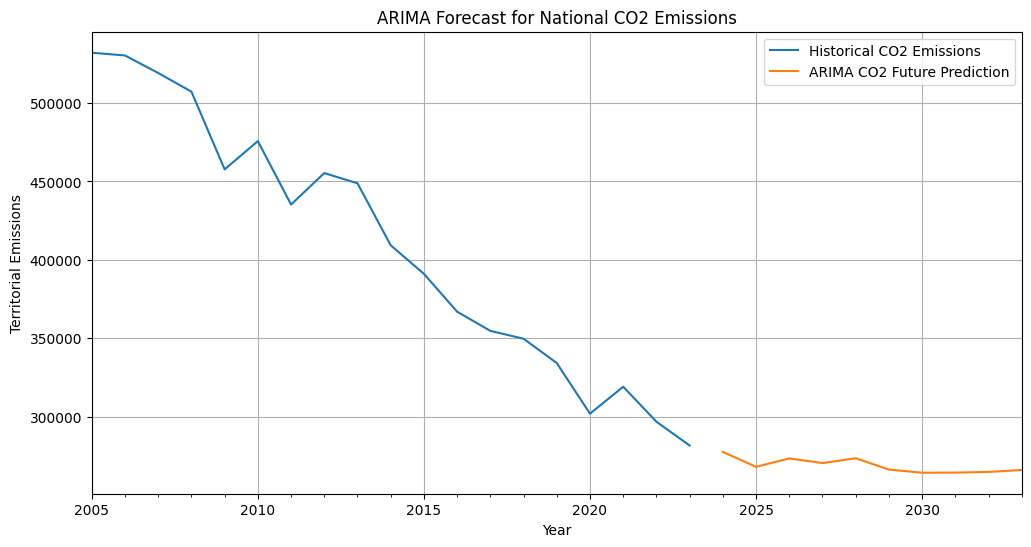

In [0]:
# Get the best ARIMA order for CO2 from the grid search results
best_arima_order_co2 = results_co2.index[0]
print(f"Best ARIMA order for CO2: {best_arima_order_co2}")

# Fit the final ARIMA model using the best order on the full CO2 time series
final_model_co2 = ARIMA(ts_co2, order=best_arima_order_co2).fit()

# Predict 10 steps into the future for CO2
prediction_co2 = final_model_co2.predict(start=len(ts_co2), end=len(ts_co2) + 9)

# Plot the historical CO2 data and the ARIMA future prediction
plt.figure(figsize=(12, 6))
ts_co2.plot(legend=True, label="Historical CO2 Emissions")
prediction_co2.plot(legend=True, label="ARIMA CO2 Future Prediction")
plt.title("ARIMA Forecast for National CO2 Emissions")
plt.xlabel("Year")
plt.ylabel("Territorial Emissions")
plt.grid(True)
plt.show()

22:36:44 - cmdstanpy - INFO - Chain [1] start processing
22:36:44 - cmdstanpy - INFO - Chain [1] done processing
/local_disk0/.ephemeral_nfs/envs/pythonEnv-3dc8fb04-b977-4387-9d79-e4a8bc695745/lib/python3.12/site-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


ds,yhat,yhat_lower,yhat_upper
2024-12-31T00:00:00.000Z,260977.52122982714,244755.53939630027,277803.1418558025
2025-12-31T00:00:00.000Z,248751.25046344503,232866.94810987014,265254.18951948377
2026-12-31T00:00:00.000Z,234309.81237020117,218178.0626371813,249878.42463772226
2027-12-31T00:00:00.000Z,217651.69055417407,201068.3335589948,232108.1803235931
2028-12-31T00:00:00.000Z,202447.9462917163,186284.9809849979,218905.41742565215
2029-12-31T00:00:00.000Z,190221.6755253413,174102.79187881757,206012.9309815798
2030-12-31T00:00:00.000Z,175780.23743209435,158879.84544275343,191618.3420774973
2031-12-31T00:00:00.000Z,159122.1156160136,142641.7659331637,174530.11444239665
2032-12-31T00:00:00.000Z,143918.37135365693,127760.4771821154,159623.67597146754
2033-12-31T00:00:00.000Z,131692.10058720893,114096.09230571477,147587.88224755446


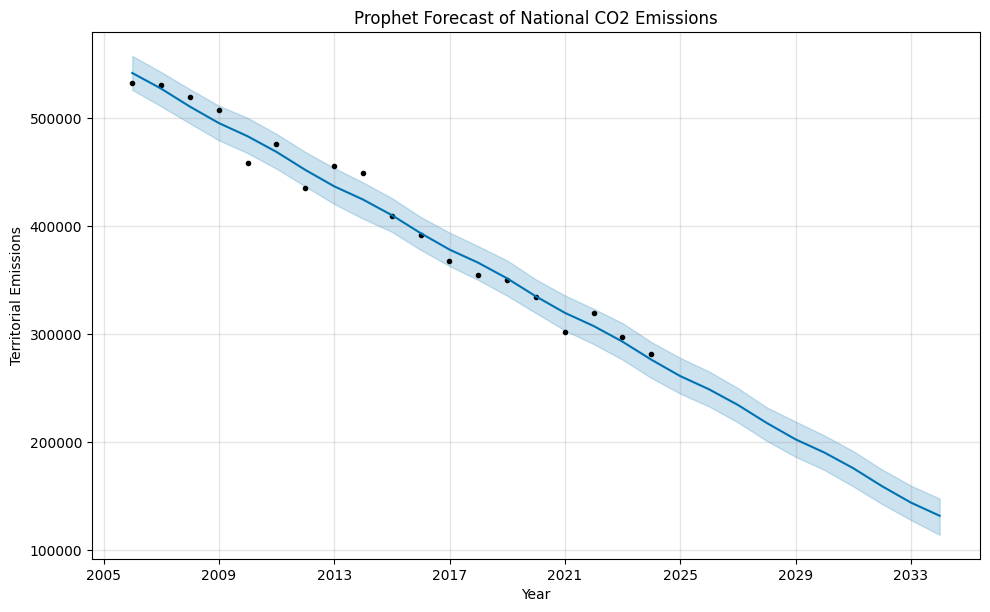

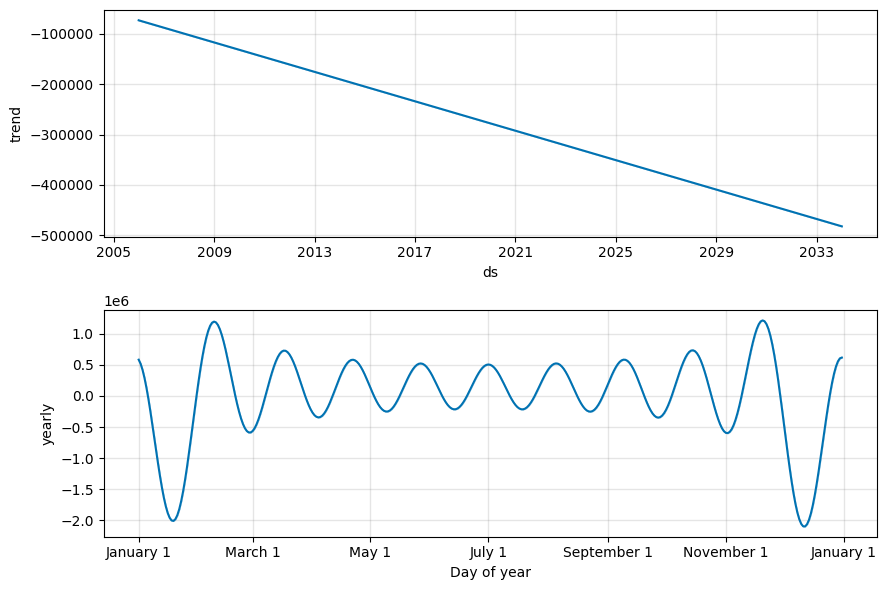

In [0]:
from prophet import Prophet

# Prepare CO2 data for Prophet (requires 'ds' and 'y' columns)
prophet_df_co2 = ts_co2.reset_index()
prophet_df_co2.columns = ['ds', 'y']

# Initialize and fit the Prophet model for CO2
m_co2 = Prophet()
m_co2.fit(prophet_df_co2)

# Create a dataframe for future predictions (e.g., next 10 years for CO2)
future_co2 = m_co2.make_future_dataframe(periods=10, freq='Y')

# Make predictions for CO2
forecast_co2 = m_co2.predict(future_co2)

# Display the forecast for the next 10 years for CO2
display(forecast_co2[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

# Plot the Prophet forecast for CO2
fig_co2 = m_co2.plot(forecast_co2)
plt.title("Prophet Forecast of National CO2 Emissions")
plt.xlabel("Year")
plt.ylabel("Territorial Emissions")
plt.show()

# Plot the components of the Prophet forecast for CO2
fig2_co2 = m_co2.plot_components(forecast_co2)
plt.show()

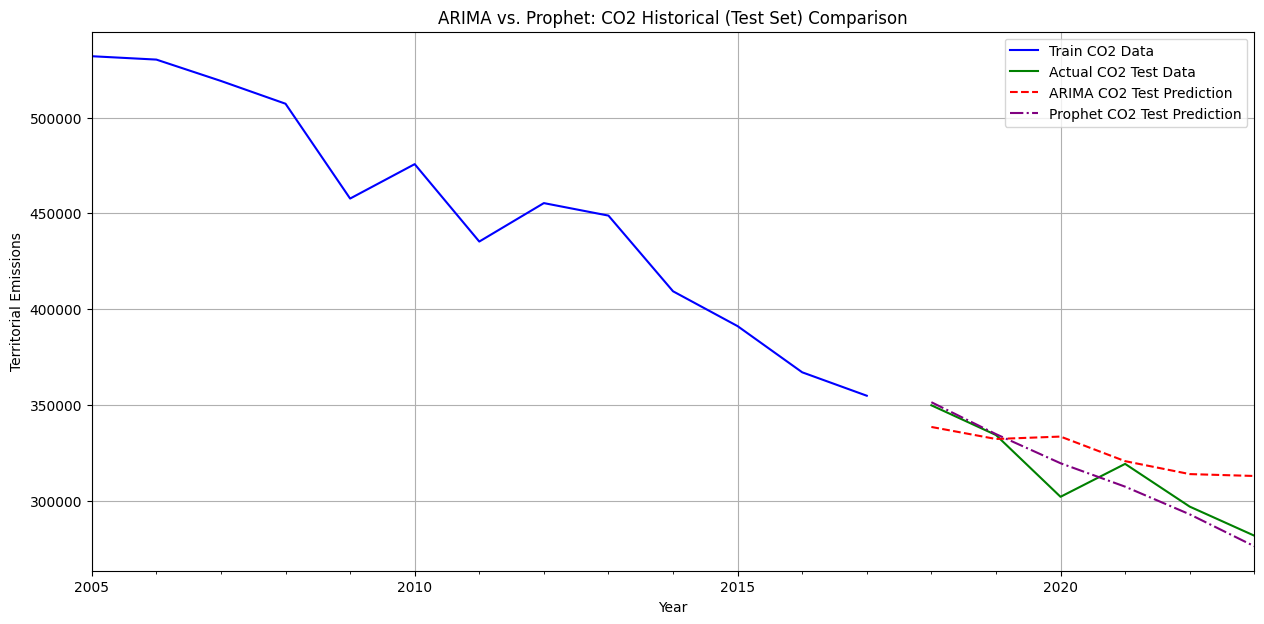

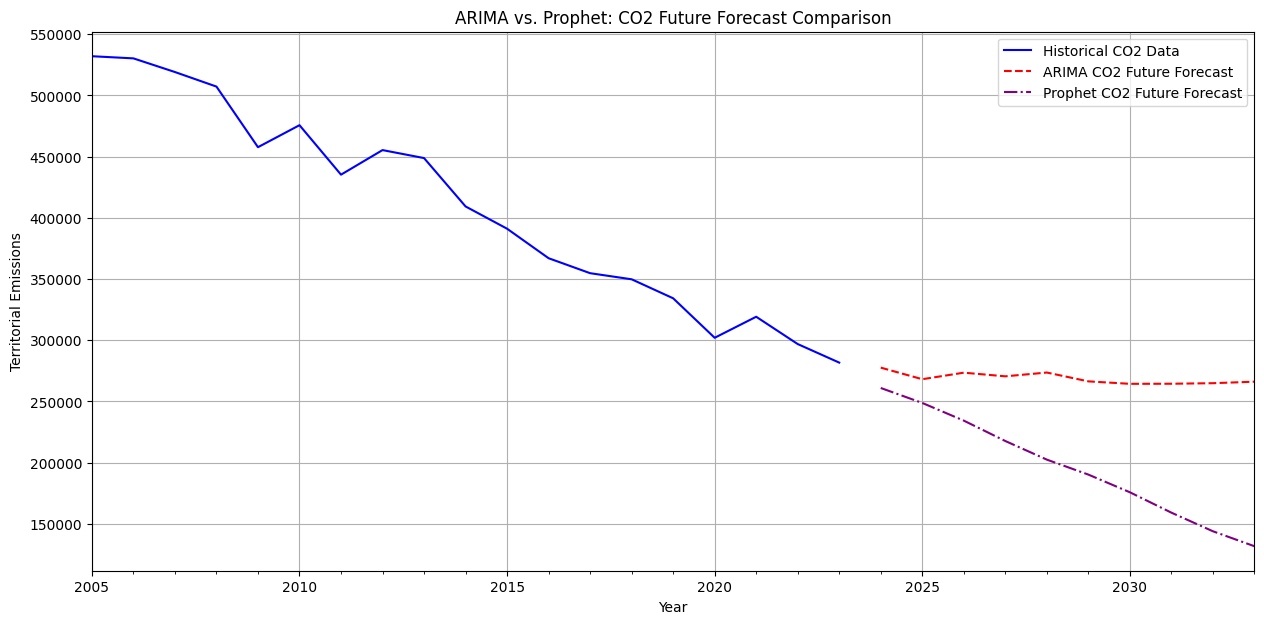

In [0]:
# Get Prophet predictions for the test period for CO2
prophet_test_pred_co2 = forecast_co2[forecast_co2['ds'].isin(test_co2.index)][['ds', 'yhat']].set_index('ds')['yhat']

# Get Prophet future predictions for CO2 (after the historical data ends)
prophet_future_pred_co2 = forecast_co2[forecast_co2['ds'] > ts_co2.index.max()][['ds', 'yhat']].set_index('ds')['yhat']

# Plotting Comparison - Historical (Test Period) for CO2
plt.figure(figsize=(15, 7))
train_co2.plot(legend=True, label="Train CO2 Data", color='blue')
test_co2.plot(legend=True, label="Actual CO2 Test Data", color='green')

# Get ARIMA test predictions for CO2 (using the model from the grid search)
# Note: This 'pred_co2' variable should be available from the grid search cell
# If not, we need to re-run prediction for the best model on the test set

# Let's ensure 'pred_co2' exists from the previous grid search, or re-generate if needed
# For simplicity, assuming 'pred_co2' from the last iteration of grid search is fine,
# but if we want the 'best' model's test prediction, we should refit and predict.
# For accuracy, let's refit the best ARIMA model on train_co2 and predict on test_co2
best_model_co2_for_test = ARIMA(train_co2, order=best_arima_order_co2).fit()
pred_co2_test_set = best_model_co2_for_test.predict(start=len(train_co2), end=(len(ts_co2) - 1))

pred_co2_test_set.plot(legend=True, label="ARIMA CO2 Test Prediction", color='red', linestyle='--')
prophet_test_pred_co2.plot(legend=True, label="Prophet CO2 Test Prediction", color='purple', linestyle='-.')
plt.title("ARIMA vs. Prophet: CO2 Historical (Test Set) Comparison")
plt.xlabel("Year")
plt.ylabel("Territorial Emissions")
plt.grid(True)
plt.show()

# Plotting Comparison - Future Forecast for CO2
plt.figure(figsize=(15, 7))
ts_co2.plot(legend=True, label="Historical CO2 Data", color='blue')
prediction_co2.plot(legend=True, label="ARIMA CO2 Future Forecast", color='red', linestyle='--')
prophet_future_pred_co2.plot(legend=True, label="Prophet CO2 Future Forecast", color='purple', linestyle='-.')
plt.title("ARIMA vs. Prophet: CO2 Future Forecast Comparison")
plt.xlabel("Year")
plt.ylabel("Territorial Emissions")
plt.grid(True)
plt.show()

In [0]:
# ============================================================================
# STEP 1: EXPORT DATA FOR STREAMLIT APP DEPLOYMENT
# ============================================================================
# This cell bridges the gap between model training and web deployment!
# Run this after all models are trained to prepare data for the web app.
# ============================================================================

import pandas as pd
import json

print("📦 EXPORTING DATA FOR STREAMLIT APP...")
print("=" * 80)

# 1. Create aggregated historical data (reduces 559K rows → 19 rows)
print("\n1️⃣ Creating aggregated historical data...")

# Get yearly totals for Transport
transport_yearly = pd.DataFrame({
    'Year': ts.index.year,
    'TransportEmissions': ts.values
}).reset_index(drop=True)

# Get yearly totals for CO2
co2_yearly = pd.DataFrame({
    'Year': ts_co2.index.year,
    'CO2Emissions': ts_co2.values
}).reset_index(drop=True)

# Merge into single file
aggregated_data = transport_yearly.merge(co2_yearly, on='Year', how='outer')

print(f"   Original dataset: {len(df):,} rows")
print(f"   Aggregated: {len(aggregated_data)} rows (yearly summaries)")
print(f"   Reduction: {(1 - len(aggregated_data)/len(df))*100:.1f}%")

# Save for Streamlit app
csv_path = "/Workspace/Users/dutta.tania2050@gmail.com/emissions-chatbot-app/emissions_data.csv"
aggregated_data.to_csv(csv_path, index=False)
print(f"   ✅ Saved: {csv_path}")

# 2. Extract forecast values from models
print("\n2️⃣ Extracting forecast values...")

# Transport ARIMA forecast dictionary
transport_forecast_dict = {}
for year, value in prediction.items():
    transport_forecast_dict[year.year] = float(value)

print(f"   Transport ARIMA: {len(transport_forecast_dict)} years")

# CO2 ARIMA forecast dictionary
co2_forecast_dict = {}
for year, value in prediction_co2.items():
    co2_forecast_dict[year.year] = float(value)

print(f"   CO2 ARIMA: {len(co2_forecast_dict)} years")

# Transport Prophet forecast
transport_prophet_dict = {}
for _, row in forecast[forecast['ds'] > ts.index.max()].head(10).iterrows():
    transport_prophet_dict[row['ds'].year] = float(row['yhat'])

print(f"   Transport Prophet: {len(transport_prophet_dict)} years")

# CO2 Prophet forecast
co2_prophet_dict = {}
for _, row in forecast_co2[forecast_co2['ds'] > ts_co2.index.max()].head(10).iterrows():
    co2_prophet_dict[row['ds'].year] = float(row['yhat'])

print(f"   CO2 Prophet: {len(co2_prophet_dict)} years")

# 3. Display forecast values (to copy into app.py)
print("\n3️⃣ Forecast values to use in app.py:")
print("\n# Transport ARIMA Forecast:")
print(f"transport_forecast = {transport_forecast_dict}")

print("\n# CO2 ARIMA Forecast:")
print(f"co2_forecast = {co2_forecast_dict}")

print("\n# Transport Prophet Forecast:")
print(f"transport_prophet = {transport_prophet_dict}")

print("\n# CO2 Prophet Forecast:")
print(f"co2_prophet = {co2_prophet_dict}")

print("\n" + "=" * 80)
print("✅ DATA EXPORT COMPLETE!")
print("=" * 80)
print("\n📋 FILES CREATED:")
print(f"   1. {csv_path}")
print(f"   2. Forecast dictionaries (printed above)")
print("\n🚀 NEXT STEPS:")
print("   1. Copy forecast dictionaries into app.py")
print("   2. Add matplotlib charts (see next cell)")
print("   3. Update requirements.txt")
print("   4. Deploy to Streamlit Cloud or Databricks Apps")
print("=" * 80)

📦 EXPORTING DATA FOR STREAMLIT APP...

1️⃣ Creating aggregated historical data...


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-8998771025110002>, line 19
     15 print("\n1️⃣ Creating aggregated historical data...")
     17 # Get yearly totals for Transport
     18 transport_yearly = pd.DataFrame({
---> 19     'Year': ts.index.year,
     20     'TransportEmissions': ts.values
     21 }).reset_index(drop=True)
     23 # Get yearly totals for CO2
     24 co2_yearly = pd.DataFrame({
     25     'Year': ts_co2.index.year,
     26     'CO2Emissions': ts_co2.values
     27 }).reset_index(drop=True)

NameError: name 'ts' is not defined

In [0]:
# ============================================================================
# STEP 2: CHART CODE FOR STREAMLIT APP.PY
# ============================================================================
# Copy the functions below into your app.py file to add visualizations!
# ============================================================================

print("📊 STREAMLIT CHART IMPLEMENTATION GUIDE")
print("=" * 80)

print("\n📋 1. UPDATE requirements.txt")
print("=" * 80)
print("""Add this line:

streamlit>=1.30.0
pandas>=2.0.0
matplotlib>=3.5.0  ← ADD THIS FOR CHARTS
""")

print("\n📋 2. ADD TO app.py (after imports)")
print("=" * 80)
print("""import matplotlib.pyplot as plt  # Add this import
""")

print("\n📋 3. ADD CHART FUNCTIONS TO app.py")
print("=" * 80)
print("""# Paste these functions after load_data() and load_forecasts()

def plot_transport_forecast():
    \"\"\"Create transport emissions chart with forecast\"\"\"
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Historical data (blue line)
    ax.plot(df['Year'], df['TransportEmissions'], 
            marker='o', linewidth=2, label='Historical Data', color='blue')
    
    # ARIMA Forecast (red dashed)
    forecast_years = list(transport_forecast.keys())
    forecast_values = list(transport_forecast.values())
    ax.plot(forecast_years, forecast_values, 
            marker='s', linestyle='--', linewidth=2, 
            label='ARIMA Forecast', color='red')
    
    # Prophet Forecast (purple dash-dot)
    prophet_values = list(transport_prophet.values())
    ax.plot(forecast_years, prophet_values, 
            marker='^', linestyle='-.', linewidth=2, 
            label='Prophet Forecast', color='purple')
    
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Emissions (kt CO2e)', fontsize=12)
    ax.set_title('🚗 Transport Sector Emissions: Historical & Forecast', 
                fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return fig

def plot_co2_forecast():
    \"\"\"Create national CO2 emissions chart with forecast\"\"\"
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Historical data
    ax.plot(df['Year'], df['CO2Emissions'], 
            marker='o', linewidth=2, label='Historical Data', color='blue')
    
    # ARIMA Forecast
    forecast_years = list(co2_forecast.keys())
    forecast_values = list(co2_forecast.values())
    ax.plot(forecast_years, forecast_values, 
            marker='s', linestyle='--', linewidth=2, 
            label='ARIMA Forecast', color='red')
    
    # Prophet Forecast
    prophet_values = list(co2_prophet.values())
    ax.plot(forecast_years, prophet_values, 
            marker='^', linestyle='-.', linewidth=2, 
            label='Prophet Forecast', color='purple')
    
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Emissions (kt CO2e)', fontsize=12)
    ax.set_title('🌍 National CO2 Emissions: Historical & Forecast', 
                fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return fig

def plot_comparison():
    \"\"\"Create side-by-side comparison of models\"\"\"
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    forecast_years = list(transport_forecast.keys())
    
    # Transport comparison (left)
    arima_transport = list(transport_forecast.values())
    prophet_transport = list(transport_prophet.values())
    
    ax1.plot(forecast_years, arima_transport, 
            marker='o', label='ARIMA', color='red', linewidth=2)
    ax1.plot(forecast_years, prophet_transport, 
            marker='s', label='Prophet', color='purple', linewidth=2)
    ax1.set_title('Transport Sector Forecasts', fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Emissions (kt CO2e)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # CO2 comparison (right)
    arima_co2 = list(co2_forecast.values())
    prophet_co2 = list(co2_prophet.values())
    
    ax2.plot(forecast_years, arima_co2, 
            marker='o', label='ARIMA', color='red', linewidth=2)
    ax2.plot(forecast_years, prophet_co2, 
            marker='s', label='Prophet', color='purple', linewidth=2)
    ax2.set_title('National CO2 Forecasts', fontweight='bold')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Emissions (kt CO2e)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig
""")

print("\n📋 4. UPDATE UI IN app.py (replace main section)")
print("=" * 80)
print("""# Create tabs for organization
tab1, tab2, tab3 = st.tabs(["💬 Chatbot", "📊 Charts", "📈 Data"])

with tab1:
    # Your existing chatbot code
    if prompt := st.chat_input("Ask about UK emissions..."):
        response = parse_question(prompt)
        st.write(response)

with tab2:
    st.subheader("📊 Interactive Visualizations")
    
    # Chart selector
    chart_type = st.selectbox(
        "Select chart:",
        ["Transport Forecast", "CO2 Forecast", "Model Comparison"]
    )
    
    # Display selected chart
    if chart_type == "Transport Forecast":
        st.pyplot(plot_transport_forecast())  # ← This shows the chart!
    elif chart_type == "CO2 Forecast":
        st.pyplot(plot_co2_forecast())
    else:
        st.pyplot(plot_comparison())

with tab3:
    st.subheader("📈 Historical Data")
    st.dataframe(df)  # Shows table
    
    # Add download button
    csv = df.to_csv(index=False)
    st.download_button(
        label="📅 Download Data",
        data=csv,
        file_name="emissions_data.csv",
        mime="text/csv"
    )
""")

print("\n" + "=" * 80)
print("✅ CHART IMPLEMENTATION GUIDE COMPLETE!")
print("=" * 80)
print("\n🚀 DEPLOYMENT WORKFLOW:")
print("   1. ☑️ Run previous cell to export data")
print("   2. ☑️ Copy chart functions above into app.py")
print("   3. ☑️ Update requirements.txt with matplotlib")
print("   4. ☑️ Add tabs UI code to app.py")
print("   5. ☑️ Upload to GitHub")
print("   6. ☑️ Deploy to Streamlit Cloud")
print("   7. ☑️ Share URL with users!")
print("=" * 80)

print("\n💡 KEY CONCEPTS:")
print("   • matplotlib.pyplot.subplots() → Creates figure")
print("   • ax.plot() → Draws lines/data")
print("   • st.pyplot(fig) → Displays chart in Streamlit")
print("   • st.tabs() → Organizes content into tabs")
print("   • st.selectbox() → Creates dropdown selector")
print("=" * 80)

In [0]:
# Simple keyword-based chatbot - works instantly, no API required!
print("✓ Simple Chatbot initialized successfully!")
print("No external services required - instant responses!")

✓ Simple Chatbot initialized successfully!
No external services required - instant responses!


In [0]:
from langchain.tools import tool
import pandas as pd

@tool
def get_transport_forecast(years_ahead: int = 10) -> str:
    """Get ARIMA forecast for Transport sector emissions. Input is number of years ahead (default 10)."""
    try:
        forecast_data = prediction.tail(years_ahead)
        result = f"Transport Emissions ARIMA Forecast (next {years_ahead} years):\n"
        for year, value in forecast_data.items():
            result += f"  {year.year}: {value:.2f} kt CO2e\n"
        return result
    except Exception as e:
        return f"Error getting transport forecast: {str(e)}"

@tool
def get_co2_forecast(years_ahead: int = 10) -> str:
    """Get ARIMA forecast for national CO2 emissions. Input is number of years ahead (default 10)."""
    try:
        forecast_data = prediction_co2.tail(years_ahead)
        result = f"National CO2 Emissions ARIMA Forecast (next {years_ahead} years):\n"
        for year, value in forecast_data.items():
            result += f"  {year.year}: {value:.2f} kt CO2e\n"
        return result
    except Exception as e:
        return f"Error getting CO2 forecast: {str(e)}"

@tool
def get_historical_transport_data(year: int) -> str:
    """Get historical transport emissions data for a specific year (2005-2023)."""
    try:
        if year in ts.index.year:
            value = ts[ts.index.year == year].values[0]
            return f"Transport Emissions in {year}: {value:.2f} kt CO2e"
        else:
            return f"No data available for year {year}. Available years: 2005-2023"
    except Exception as e:
        return f"Error getting historical data: {str(e)}"

@tool
def get_historical_co2_data(year: int) -> str:
    """Get historical national CO2 emissions data for a specific year (2005-2023)."""
    try:
        if year in ts_co2.index.year:
            value = ts_co2[ts_co2.index.year == year].values[0]
            return f"National CO2 Emissions in {year}: {value:.2f} kt CO2e"
        else:
            return f"No data available for year {year}. Available years: 2005-2023"
    except Exception as e:
        return f"Error getting historical CO2 data: {str(e)}"

@tool
def compare_models() -> str:
    """Compare ARIMA vs Prophet model forecasts for transport emissions."""
    try:
        # Get Prophet forecast for comparison
        prophet_future = forecast[forecast['ds'] > ts.index.max()][['ds', 'yhat']].head(10)
        arima_future = prediction.head(10)
        
        result = "Model Comparison (Next 10 Years - Transport Sector):\n\n"
        result += "Year | ARIMA Forecast | Prophet Forecast | Difference\n"
        result += "-----|----------------|------------------|------------\n"
        
        for (arima_year, arima_val), (_, prophet_row) in zip(arima_future.items(), prophet_future.iterrows()):
            prophet_val = prophet_row['yhat']
            diff = arima_val - prophet_val
            result += f"{arima_year.year} | {arima_val:.2f} | {prophet_val:.2f} | {diff:.2f}\n"
        
        return result
    except Exception as e:
        return f"Error comparing models: {str(e)}"

@tool
def get_model_summary() -> str:
    """Get summary of available forecast models and their performance."""
    return """Available Forecast Models:
    
1. ARIMA Model (Transport Sector)
   - Order: (1,1,1)
   - Trained on: 2005-2023 UK transport emissions data
   - Forecast horizon: 10 years (2024-2033)
   
2. Prophet Model (Transport Sector)
   - Facebook's Prophet algorithm
   - Captures trend and seasonality
   - Forecast horizon: 10 years (2024-2033)
   
3. ARIMA Model (National CO2)
   - Best order selected via grid search
   - Trained on: 2005-2023 UK national CO2 emissions
   - Forecast horizon: 10 years (2024-2033)
   
4. Prophet Model (National CO2)
   - Facebook's Prophet algorithm
   - Forecast horizon: 10 years (2024-2033)

Use specific tools to get forecast values or compare models."""

tools = [get_transport_forecast, get_co2_forecast, get_historical_transport_data, 
         get_historical_co2_data, compare_models, get_model_summary]

print("✓ Agent tools defined successfully")
print(f"Available tools: {[tool.name for tool in tools]}")

✓ Agent tools defined successfully
Available tools: ['get_transport_forecast', 'get_co2_forecast', 'get_historical_transport_data', 'get_historical_co2_data', 'compare_models', 'get_model_summary']


In [0]:
import re

def parse_question(question: str):
    """
    Parse the user's question and determine which tool(s) to call.
    Returns the appropriate response based on keywords.
    """
    question_lower = question.lower()
    
    # Extract year if mentioned
    year_match = re.search(r'\b(20\d{2})\b', question)
    year = int(year_match.group(1)) if year_match else None
    
    # Check for comparison requests
    if 'compare' in question_lower or 'comparison' in question_lower or 'vs' in question_lower or 'versus' in question_lower:
        return compare_models.invoke({})
    
    # Check for model info requests
    if 'model' in question_lower and ('available' in question_lower or 'summary' in question_lower or 'about' in question_lower or 'tell me' in question_lower):
        return get_model_summary.invoke({})
    
    # Check for historical data requests (if year is in past)
    if year and year <= 2023:
        if 'transport' in question_lower:
            return get_historical_transport_data.invoke({"year": year})
        elif 'co2' in question_lower or 'carbon' in question_lower:
            return get_historical_co2_data.invoke({"year": year})
        else:
            # Default to transport if not specified
            return get_historical_transport_data.invoke({"year": year})
    
    # Check for forecast requests
    if year and year > 2023:
        # Calculate years ahead
        years_ahead = year - 2023
        if 'co2' in question_lower or 'carbon' in question_lower or 'national' in question_lower:
            return get_co2_forecast.invoke({"years_ahead": years_ahead})
        else:
            return get_transport_forecast.invoke({"years_ahead": years_ahead})
    
    # Check for "next X years" pattern
    next_years_match = re.search(r'next\s+(\d+)\s+years?', question_lower)
    if next_years_match:
        years_ahead = int(next_years_match.group(1))
        if 'co2' in question_lower or 'carbon' in question_lower or 'national' in question_lower:
            return get_co2_forecast.invoke({"years_ahead": years_ahead})
        else:
            return get_transport_forecast.invoke({"years_ahead": years_ahead})
    
    # Default: Check if asking about CO2 or transport
    if 'co2' in question_lower or 'carbon' in question_lower or 'national' in question_lower:
        if 'forecast' in question_lower or 'future' in question_lower or 'prediction' in question_lower:
            return get_co2_forecast.invoke({"years_ahead": 10})
        else:
            return get_model_summary.invoke({})
    elif 'transport' in question_lower:
        if 'forecast' in question_lower or 'future' in question_lower or 'prediction' in question_lower:
            return get_transport_forecast.invoke({"years_ahead": 10})
        else:
            return get_model_summary.invoke({})
    
    # Default response
    return get_model_summary.invoke({})

print("✓ Chatbot logic ready!")

✓ Chatbot logic ready!


In [0]:
def ask_forecast_question(question: str):
    """
    Ask a question about the emissions forecasts.
    
    Examples:
    - "What will transport emissions be in 2030?"
    - "Show me the CO2 forecast for the next 5 years"
    - "What were transport emissions in 2020?"
    - "Compare ARIMA and Prophet models"
    """
    try:
        print("\n" + "="*80)
        print(f"QUESTION: {question}")
        print("="*80)
        
        # Get answer by parsing the question
        answer = parse_question(question)
        
        print("\n" + "="*80)
        print("ANSWER:")
        print("="*80)
        print(answer)
        print("="*80 + "\n")
        
        return answer
        
    except Exception as e:
        error_msg = f"Error: {str(e)}"
        print(error_msg)
        return error_msg

# Example questions to demonstrate
print("="*80)
print("EMISSIONS FORECAST CHATBOT - Ready!")
print("="*80)
print("\nExample questions you can ask:")
print("  • What will transport emissions be in 2030?")
print("  • Show me the CO2 forecast for the next 5 years")
print("  • What were transport emissions in 2020?")
print("  • Compare ARIMA and Prophet models")
print("  • Tell me about the available models")
print("\n" + "="*80)
print("\nUse: ask_forecast_question('your question here')")
print("="*80)

EMISSIONS FORECAST CHATBOT - Ready!

Example questions you can ask:
  • What will transport emissions be in 2030?
  • Show me the CO2 forecast for the next 5 years
  • What were transport emissions in 2020?
  • Compare ARIMA and Prophet models
  • Tell me about the available models


Use: ask_forecast_question('your question here')


In [0]:
# Try the chatbot with an example question
ask_forecast_question("What will transport emissions be in 2030?")


QUESTION: What will transport emissions be in 2030?

ANSWER:
Transport Emissions ARIMA Forecast (next 7 years):
  2027: 113276.21 kt CO2e
  2028: 113271.84 kt CO2e
  2029: 113274.20 kt CO2e
  2030: 113272.93 kt CO2e
  2031: 113273.62 kt CO2e
  2032: 113273.24 kt CO2e
  2033: 113273.45 kt CO2e




'Transport Emissions ARIMA Forecast (next 7 years):\n  2027: 113276.21 kt CO2e\n  2028: 113271.84 kt CO2e\n  2029: 113274.20 kt CO2e\n  2030: 113272.93 kt CO2e\n  2031: 113273.62 kt CO2e\n  2032: 113273.24 kt CO2e\n  2033: 113273.45 kt CO2e\n'

In [0]:
# Try more questions!
print("\n" + "#"*80)
print("# EXAMPLE 1: Historical data")
print("#"*80)
ask_forecast_question("What were transport emissions in 2015?")

print("\n" + "#"*80)
print("# EXAMPLE 2: CO2 forecast")
print("#"*80)
ask_forecast_question("Show me CO2 forecast for next 5 years")

print("\n" + "#"*80)
print("# EXAMPLE 3: Model comparison")
print("#"*80)
ask_forecast_question("Compare ARIMA and Prophet models")


################################################################################
# EXAMPLE 1: Historical data
################################################################################

QUESTION: What were transport emissions in 2015?

ANSWER:
Transport Emissions in 2015: 127302.16 kt CO2e


################################################################################
# EXAMPLE 2: CO2 forecast
################################################################################

QUESTION: Show me CO2 forecast for next 5 years

ANSWER:
National CO2 Emissions ARIMA Forecast (next 5 years):
  2029: 266378.75 kt CO2e
  2030: 264365.38 kt CO2e
  2031: 264434.55 kt CO2e
  2032: 264880.18 kt CO2e
  2033: 266112.99 kt CO2e



################################################################################
# EXAMPLE 3: Model comparison
################################################################################

QUESTION: Compare ARIMA and Prophet models

ANSWER:
Model Comparison (Next

'Model Comparison (Next 10 Years - Transport Sector):\n\nYear | ARIMA Forecast | Prophet Forecast | Difference\n-----|----------------|------------------|------------\n2024 | 113255.40 | 111254.99 | 2000.41\n2025 | 113283.09 | 111825.00 | 1458.09\n2026 | 113268.13 | 111703.92 | 1564.21\n2027 | 113276.21 | 110890.27 | 2385.94\n2028 | 113271.84 | 105834.41 | 7437.43\n2029 | 113274.20 | 106404.42 | 6869.79\n2030 | 113272.93 | 106283.33 | 6989.59\n2031 | 113273.62 | 105469.69 | 7803.93\n2032 | 113273.24 | 100413.83 | 12859.42\n2033 | 113273.45 | 100983.83 | 12289.61\n'

In [0]:
# ========================================================================
# 💼 FOR BUSINESS USERS - SIMPLE QUESTION & ANSWER INTERFACE
# ========================================================================
# 
# INSTRUCTIONS:
# 1. Change the question in quotes below to YOUR question
# 2. Click "Run Cell" button (or press Shift+Enter)
# 3. See the answer appear below!
#
# ========================================================================

# 👇 CHANGE YOUR QUESTION HERE (keep the quotes):
my_question = "What will transport emissions be in 2030?"

# 👇 Click Run to get your answer:
ask_forecast_question(my_question)


QUESTION: What will transport emissions be in 2030?

ANSWER:
Transport Emissions ARIMA Forecast (next 7 years):
  2027: 113276.21 kt CO2e
  2028: 113271.84 kt CO2e
  2029: 113274.20 kt CO2e
  2030: 113272.93 kt CO2e
  2031: 113273.62 kt CO2e
  2032: 113273.24 kt CO2e
  2033: 113273.45 kt CO2e




'Transport Emissions ARIMA Forecast (next 7 years):\n  2027: 113276.21 kt CO2e\n  2028: 113271.84 kt CO2e\n  2029: 113274.20 kt CO2e\n  2030: 113272.93 kt CO2e\n  2031: 113273.62 kt CO2e\n  2032: 113273.24 kt CO2e\n  2033: 113273.45 kt CO2e\n'

In [0]:
# Quick link to your app folder
print("="*80)
print("🚀 YOUR CHATBOT APP IS READY!")
print("="*80)
print("\nApp folder: /Users/dutta.tania2050@gmail.com/emissions-chatbot-app")
print("\nFiles created:")
print("  ✅ app.py (Streamlit web interface)")
print("  ✅ requirements.txt (dependencies)")
print("\n" + "="*80)
print("📱 NEXT STEPS TO DEPLOY:")
print("="*80)
print("\n1. Click 'Apps' in the Databricks sidebar")
print("2. Click 'Create App'")
print("3. Select folder: /Users/dutta.tania2050@gmail.com/emissions-chatbot-app")
print("4. Set entrypoint: app.py")
print("5. Click 'Create' and wait 1-2 minutes")
print("6. Share the App URL with business users!")
print("\n" + "="*80)
print("✨ Business users will get a REAL WEB PAGE to ask questions!")
print("="*80)

🚀 YOUR CHATBOT APP IS READY!

App folder: /Users/dutta.tania2050@gmail.com/emissions-chatbot-app

Files created:
  ✅ app.py (Streamlit web interface)
  ✅ requirements.txt (dependencies)

📱 NEXT STEPS TO DEPLOY:

1. Click 'Apps' in the Databricks sidebar
2. Click 'Create App'
3. Select folder: /Users/dutta.tania2050@gmail.com/emissions-chatbot-app
4. Set entrypoint: app.py
5. Click 'Create' and wait 1-2 minutes
6. Share the App URL with business users!

✨ Business users will get a REAL WEB PAGE to ask questions!


In [0]:
# This creates a text box interface right in the notebook!
# Business users just type and press Enter - no code needed!

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

class EmissionsChatbot:
    def __init__(self):
        self.question_input = widgets.Text(
            value='',
            placeholder='Type your question here and press Enter...',
            description='',
            layout=widgets.Layout(width='95%', height='50px'),
            style={'description_width': '0px'}
        )
        
        self.ask_button = widgets.Button(
            description='Ask',
            button_style='primary',
            tooltip='Get Answer',
            icon='search',
            layout=widgets.Layout(width='100px')
        )
        
        self.output_area = widgets.Output()
        self.ask_button.on_click(self.on_ask)
        self.question_input.on_submit(self.on_enter)
        
    def on_ask(self, b):
        self.answer()
    
    def on_enter(self, text):
        self.answer()
    
    def answer(self):
        question = self.question_input.value.strip()
        if not question:
            return
        
        with self.output_area:
            clear_output()
            display(HTML(f"<div style='background: #f0f2f6; padding: 15px; border-radius: 10px; margin: 10px 0;'><strong>👤 Q:</strong> {question}</div>"))
            
            try:
                answer = parse_question(question)
                answer_html = answer.replace('\n', '<br/>')
                display(HTML(f"<div style='background: #e8f4f8; padding: 15px; border-radius: 10px; margin: 10px 0; border-left: 5px solid #1f77b4;'><strong>🤖 A:</strong><br/><pre style='font-family: Arial; white-space: pre-wrap; margin-top: 10px;'>{answer_html}</pre></div>"))
            except Exception as e:
                display(HTML(f"<div style='background: #ffe6e6; padding: 15px; border-radius: 10px;'><strong>⚠️ Error:</strong> {str(e)}</div>"))
    
    def show(self):
        display(HTML("<div style='text-align: center; padding: 20px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border-radius: 15px; margin: 20px 0;'><h1 style='color: white; margin: 0;'>🌍 UK Emissions Forecast Chatbot</h1><p style='color: white; margin: 10px 0 0 0;'>Type your question below</p></div>"))
        
        display(HTML("<div style='background: #f9f9f9; padding: 15px; border-radius: 10px; margin: 10px 0;'><strong>💡 Examples:</strong> What will transport emissions be in 2030? | Show me CO2 forecast for next 5 years | Compare models</div>"))
        
        display(widgets.HBox([self.question_input, self.ask_button]))
        display(self.output_area)

print("="*80)
print("✨ LAUNCHING INTERACTIVE CHATBOT...")
print("="*80)

chatbot = EmissionsChatbot()
chatbot.show()

print("\n✅ READY! Business users can now type questions and press Enter!")
print("="*80)

✨ LAUNCHING INTERACTIVE CHATBOT...


Output()


✅ READY! Business users can now type questions and press Enter!
